# ManAHL Trend EA — Python test run

**What this is:** a mechanics test of `ManAhl_EA.mq5` v2, ported to Python
(`quantlab/strategies/manahl_trend.py`). It runs the EA's **default inputs** on 4 symbols over the development window.

**What it is not:** evidence of an edge. There's no parameter search, so it counts as one trial. The holdout period isn't touched, and swap rates aren't calibrated yet.

| Item | Value |
|---|---|
| Symbols | EURUSD, GBPJPY, NZDCHF, XAUUSD (FBS, server time EET) |
| Timeframe | D1, built from M1 data and checked against the MT5 daily exports |
| Window | 2016-05-03 → 2025-05-14. The holdout (≥ 2025-05-15) is locked by `quantlab.data` |
| Account | USD 100,000, hedging |

Sections: 1 Setup · 2 Data · 3 Costs · 4 Indicators · 5 Port verification · 6 Baseline run · 7 Behaviour diagnostics · 8 Cost sensitivity · 9 Evidence and findings · 10 Why the early kill · 11 Can the idea be saved? · 12 Run record

## 1. Setup
All strategy logic lives in `quantlab`; this notebook only loads data, calls it and reports. `PARAMS` holds the EA v2 defaults. The one difference: `days_per_year = 260`, the project's FX convention, instead of the EA's 252.

In [1]:
import sys, json, math, subprocess, warnings
from dataclasses import replace
from datetime import datetime, timedelta
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "quantlab").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from quantlab import data, costs, metrics, ledger, stats
from quantlab.costs import CostModel
from quantlab.engine import run_backtest
from quantlab.testing import assert_no_lookahead
from quantlab.strategies import manahl_trend as mt

pl.Config.set_tbl_rows(30); pl.Config.set_tbl_cols(20); pl.Config.set_float_precision(4)

SYMBOLS = ["EURUSD", "GBPJPY", "NZDCHF", "XAUUSD"]
START   = datetime(2016, 5, 3)          # first day every symbol AND its conversion leg (USDCHF, USDJPY) has data
EQUITY0 = 100_000.0
PARAMS  = mt.ManAhlParams()             # EA v2 defaults
COST    = CostModel()                   # base cost model: spread from data, no extra slippage
OUT_DIR = Path.cwd() / "results"; OUT_DIR.mkdir(exist_ok=True)

# chart style: fixed categorical order (one hue per symbol, never re-assigned), recessive grid
COLORS = dict(zip(SYMBOLS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
INK, MUTED, GRID = "#262624", "#6b6a63", "#e6e5df"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "lines.linewidth": 1.6,
                     "font.size": 9.5, "axes.titlesize": 10.5, "axes.titleweight": "bold", "legend.frameon": False})

pl.DataFrame({"param": list(PARAMS.as_dict()), "value": [str(v) for v in PARAMS.as_dict().values()]})

param,value
str,str
"""lookback_mode""","""scaled"""
"""lookback_base""","""20"""
"""lookbacks""","""(20, 60, 120, 240)"""
"""thresh_mode""","""volz"""
"""pct_up""","""0.0"""
"""pct_down""","""0.0"""
"""z_min""","""0.0"""
"""vol_period""","""60"""
"""position_mode""","""scaled"""


## 2. Data
**Why:** the EA reads MT5 daily bars, which open at server midnight (EET). The backtest has to see exactly those bars, and nothing from the holdout.

**What:**
- Build D1 bars from the M1 archive with `data.load_bars(sym, "D1")`. This is the project standard. It also gives `spread_max`, the worst spread inside each bar, which the conservative stop and short fills use (DESIGN §4.3).
- Cross-check every OHLC value against your MT5 daily exports, converted to Parquet with `tools/mt5_csv_to_parquet.py`.
- The loader cuts everything at the holdout start (DESIGN §4.1). The last bar should therefore be 2025-05-14.

In [2]:
cat_d1 = data.catalog("FBS").filter(pl.col("timeframe") == "D1")
bars, check = {}, []
for s in SYMBOLS:
    b = data.load_bars(s, "D1", start=START)                                   # M1 -> D1, holdout-locked
    x = data.load_bars(s, "D1", source_file=cat_d1.filter(pl.col("symbol") == s)["file"][0])  # MT5 export
    pt = data.infer_point(s)
    j = b.join(x, on="ts", how="inner", suffix="_mt5")
    diffs = {f"max|Δ{c}| pts": float(((j[c] - j[c + "_mt5"]).abs().max()) / pt) for c in ("open", "high", "low", "close")}
    diffs["spread_min = MT5 spread"] = float((j["spread_min"] == j["spread_mt5"]).mean())   # audit 2026-10-07
    check.append({"symbol": s, "bars (M1→D1)": b.height, "bars (MT5 export, dev)": x.height,
                  "common dates": j.height, "export dates missing in M1": x.join(b, on="ts", how="anti").height,
                  **diffs, "first": b["ts"].min().date(), "last": b["ts"].max().date()})
    bars[s] = b
pl.DataFrame(check)

symbol,bars (M1→D1),"bars (MT5 export, dev)",common dates,export dates missing in M1,max|Δopen| pts,max|Δhigh| pts,max|Δlow| pts,max|Δclose| pts,spread_min = MT5 spread,first,last
str,i64,i64,i64,i64,f64,f64,f64,f64,f64,date,date
"""EURUSD""",2351,2243,2243,0,0.0000,0.0000,0.0000,0.0000,1.0000,2016-05-03,2025-05-14
"""GBPJPY""",2351,2243,2243,0,0.0000,0.0000,0.0000,0.0000,1.0000,2016-05-03,2025-05-14
"""NZDCHF""",2340,2243,2243,0,0.0000,0.0000,0.0000,0.0000,1.0000,2016-05-03,2025-05-14
"""XAUUSD""",2238,2199,2199,0,0.0000,0.0000,0.0000,0.0000,1.0000,2016-05-03,2025-05-14


**Result:** wherever both sources have a bar, the M1-built bars match the MT5 export **to the point** on every OHLC value, and the export has no date the M1 data lacks. MT5's own daily spread equals our `spread_min` (the minimum M1 spread of the day) on 100% of days, confirming the spread audit. The M1 series also starts 4.5 months earlier (2016-05 vs 2016-09), which is why it's the source used. The last bar is 2025-05-14, so the holdout is excluded.

## 3. Costs and currency conversion
**Why:** a trend-follower's edge is small per trade, so cost assumptions change the conclusion.

**What:**
- **Instrument specs:** `costs.load_instrument` returns contract size, lot step and swap. No broker export (`ExportBrokerSpecs.mq5`) exists yet, so these are **uncalibrated defaults with swap = 0 and commission = 0**. Since positions last weeks, swap is the biggest missing cost here.
- **Spread:** the bar's own recorded spread. Fills follow the engine's conventions: a long pays the spread on entry, a short pays it on exit, and stops fill at the stop level or at the open if price gaps through.
- **Conversion to USD:** `data.conversion_rate` gives the rate known *at* each bar's open and close, from the last completed M1 bar. This avoids look-ahead.
- **Spread by hour:** the EA trades on the first tick of the day (00:00 server time), which is the daily rollover. The chart shows what that costs.
- **What the spread field means** (audit `research/audits/2026-10-07_bar_spread_semantics.md`):
  - MT5's native H1/D1 bar spread is exactly the **minimum** of the M1 spreads inside the bar (100% match).
  - Our D1 bars instead carry the spread of the day's *first* M1 bar: the rollover minute, about 2.4–3× the daytime level on FX.
  - What the M1 field itself means (first tick or per-minute minimum) can't be checked without FX tick data. If it's a minimum, the real 00:00 fill could cost up to about 2× more on FX.
  - §8 therefore adds an upper-bound run built with `costs.conservative_spread`.

In [3]:
specs, inputs = {}, []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")              # one-time "uncalibrated fallback" warnings, reported in the table instead
    for s in SYMBOLS:
        specs[s] = costs.load_instrument(s)
for s in SYMBOLS:
    b, q = bars[s], specs[s].quote_ccy
    r_open  = data.conversion_rate(q, "USD", b["ts_utc"]).to_numpy()
    r_close = data.conversion_rate(q, "USD", b["ts_utc"] + timedelta(days=1)).to_numpy()
    inputs.append(mt.SymbolInput(s, b, specs[s], r_open, r_close))

pl.DataFrame([{"symbol": s, "calibrated": sp.calibrated, "contract": sp.contract_size, "point": sp.point,
               "quote ccy": sp.quote_ccy, "swap mode": sp.swap_mode, "swap long": sp.swap_long,
               "swap short": sp.swap_short, "commission/lot": sp.commission_per_lot_rt,
               "median D1-open spread (pts)": float(bars[s]["spread"].median())} for s, sp in specs.items()])

symbol,calibrated,contract,point,quote ccy,swap mode,swap long,swap short,commission/lot,median D1-open spread (pts)
str,bool,f64,f64,str,str,f64,f64,f64,f64
"""EURUSD""",false,100000.0000,0.0000,"""USD""","""points""",0.0000,0.0000,0.0000,32.0000
"""GBPJPY""",false,100000.0000,0.0010,"""JPY""","""points""",0.0000,0.0000,0.0000,117.0000
"""NZDCHF""",false,100000.0000,0.0000,"""CHF""","""points""",0.0000,0.0000,0.0000,109.0000
"""XAUUSD""",false,100.0000,0.0100,"""USD""","""points""",0.0000,0.0000,0.0000,42.0000


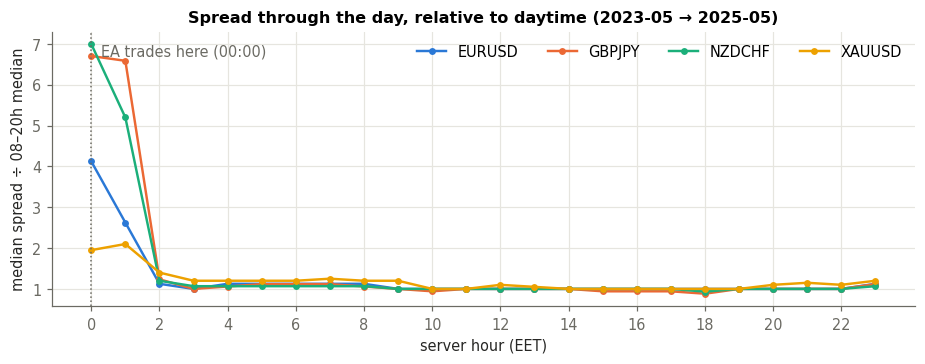

symbol,00:00 spread (pts),08–20h spread (pts),ratio
str,f64,f64,f64
"""EURUSD""",33.0000,8.0000,4.1250
"""GBPJPY""",114.0000,17.0000,6.7059
"""NZDCHF""",105.0000,15.0000,7.0000
"""XAUUSD""",39.0000,20.0000,1.9500


In [4]:
# median spread by server hour (H1 bars: spread of each hour's first minute), last two dev years
hourly = []
for s in SYMBOLS:
    h = data.load_bars(s, "H1", start=datetime(2023, 5, 15))
    hourly.append(h.group_by(pl.col("ts").dt.hour().alias("hour")).agg(pl.col("spread").median().alias("spread"))
                   .with_columns(pl.lit(s).alias("symbol")))
hourly = pl.concat(hourly).sort("symbol", "hour")
day = hourly.filter(pl.col("hour").is_between(8, 20)).group_by("symbol").agg(pl.col("spread").median().alias("day"))
hourly = hourly.join(day, on="symbol").with_columns((pl.col("spread") / pl.col("day")).alias("x_day"))

fig, ax = plt.subplots(figsize=(8.5, 3.4))
for s in SYMBOLS:
    d = hourly.filter(pl.col("symbol") == s)
    ax.plot(d["hour"], d["x_day"], color=COLORS[s], marker="o", markersize=3.5, label=s)
ax.axvline(0, color=MUTED, lw=1, ls=":"); ax.text(0.3, ax.get_ylim()[1] * 0.92, "EA trades here (00:00)", color=MUTED)
ax.set(xlabel="server hour (EET)", ylabel="median spread ÷ 08–20h median", xticks=range(0, 24, 2),
       title="Spread through the day, relative to daytime (2023-05 → 2025-05)")
ax.legend(ncol=4, loc="upper right"); plt.tight_layout(); plt.show()

hourly.filter(pl.col("hour") == 0).select("symbol", pl.col("spread").alias("00:00 spread (pts)"),
                                          pl.col("day").alias("08–20h spread (pts)"), pl.col("x_day").alias("ratio"))

## 4. Indicators
**Why:** to see what the signal looks like before trusting any P&L. Formulas are exactly those in the MQL5 v2 code, with bar *t* the last closed bar:

| Indicator | Formula | Reference |
|---|---|---|
| **σ** (volatility) | sample st.dev. of the last 60 daily log returns | Harvey et al. (2018), volatility targeting |
| **Trend score** ∈ [−4, 4] | sum over L ∈ {20, 60, 120, 240} of sign(z_L), where z_L = ln(C_t/C_{t−L}) / (σ√L) and \|z_L\| ≥ z_min (0 by default) | Moskowitz, Ooi & Pedersen (2012); Baltas & Kosowski (2013) on multiple lookbacks |
| **Efficiency ratio** ∈ [−100, 100] | 100·(C_t − C_{t−10}) / Σ\|C_j − C_{j−1}\| | Kaufman (1995), *Smarter Trading* |
| **ATR(20)** | simple mean of true range (same as MT5 `iATR`) | Wilder (1978) |

Dividing by σ√L puts every lookback on the same scale, and every symbol too. With z_min = 0 each vote is just the sign of the L-day return. The chart shows XAUUSD for the last 3 dev years.

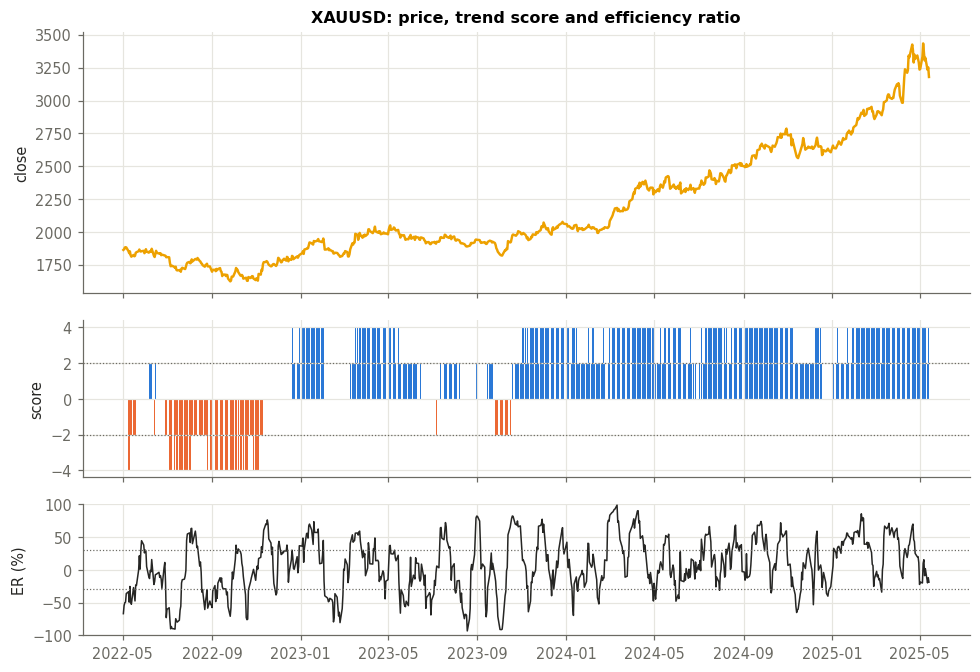

symbol,P(score=-4),P(score=-2),P(score=+0),P(score=+2),P(score=+4),P(|ER|≥30)
str,f64,f64,f64,f64,f64,f64
"""EURUSD""",0.2766,0.1890,0.1459,0.1819,0.2065,0.4524
"""GBPJPY""",0.1085,0.1521,0.1999,0.2482,0.2913,0.4964
"""NZDCHF""",0.3038,0.2933,0.2257,0.1114,0.0652,0.4495
"""XAUUSD""",0.0796,0.1166,0.2132,0.2227,0.3674,0.4690


In [5]:
s = "XAUUSD"
f = bars[s].select("ts", "close").hstack(mt.features(bars[s], PARAMS)).filter(pl.col("ts") >= datetime(2022, 5, 1))
t = f["ts"].to_numpy()
fig, axs = plt.subplots(3, 1, figsize=(9, 6.2), sharex=True, gridspec_kw={"height_ratios": [2, 1.2, 1]})
axs[0].plot(t, f["close"], color=COLORS[s]); axs[0].set(title=f"{s}: price, trend score and efficiency ratio", ylabel="close")
sc = f["score"].to_numpy().astype(float)
axs[1].bar(t, sc, width=1.0, color=np.where(sc > 0, "#2a78d6", np.where(sc < 0, "#eb6834", GRID)))
axs[1].set(ylabel="score", yticks=[-4, -2, 0, 2, 4])
for y in (2, -2): axs[1].axhline(y, color=MUTED, lw=0.8, ls=":")
axs[2].plot(t, f["er"], color=INK, lw=1.0)
for y in (PARAMS.er_min, -PARAMS.er_min): axs[2].axhline(y, color=MUTED, lw=0.8, ls=":")
axs[2].set(ylabel="ER (%)", ylim=(-100, 100)); axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

allf = pl.concat([mt.features(bars[s], PARAMS).with_columns(pl.lit(s).alias("symbol")) for s in SYMBOLS]).drop_nulls("score")
allf.group_by("symbol").agg(*[(pl.col("score") == k).mean().alias(f"P(score={k:+d})") for k in (-4, -2, 0, 2, 4)],
                            ((pl.col("er").abs() >= PARAMS.er_min).mean()).alias("P(|ER|≥30)")).sort("symbol")

**How to read it:** the score is mostly at ±4 or ±2, and the table shows how often each level occurs. The ER filter (|ER| ≥ 30 over 10 days) only lets a position open or grow when the last two weeks were a clean move. It never forces an exit.

## 5. Port verification
**Why:** a backtest is only as good as the code under it. Three independent checks, each covering a different way the port could be wrong:

1. **Unit tests** (`tests/test_strategy_manahl_trend.py`, 32 tests). Indicator values against literal loop ports of the MQL5 functions; the position-rule table; hand-built price paths for stop fills, gaps, re-entry after a stop, scaling down and swap weights.
2. **Look-ahead audit on real data** (`quantlab.testing.assert_no_lookahead`). The signal at row *t* must not change when the data is truncated at *t* or the future is replaced with random paths.
3. **Engine parity.** In all-or-nothing mode with no stop, the simulator must reproduce `quantlab.engine` fill for fill. The engine is the project's already-verified backtest engine, so this pins down entry/exit timing and spread handling.

In [6]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-o", "addopts=",
                    str(ROOT / "tests/test_strategy_manahl_trend.py")],
                   cwd=ROOT, capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])
assert r.returncode == 0

33 passed in 2.84s


In [7]:
P_BIN = replace(PARAMS, position_mode="binary_full", stop_mode="none", sizing_mode="fixed", fixed_lots=1.0)
for s in SYMBOLS:
    assert_no_lookahead(lambda: mt.ManAhlTrend(replace(P_BIN, stop_mode="atr")), bars[s], n_checks=10, min_history=300)
print("look-ahead audit: passed on", ", ".join(SYMBOLS))

rows = []
for si in inputs:
    eng = run_backtest(si.bars, mt.ManAhlTrend(P_BIN).signals(si.bars), si.spec).trades.sort("entry_ts")
    sim = mt.simulate([si], P_BIN).trades.sort("entry_ts")
    same = eng.height == sim.height and all(eng[c].cast(sim[c].dtype).equals(sim[c])
                                            for c in ("entry_ts", "exit_ts", "entry_price", "exit_price"))
    rows.append({"symbol": si.symbol, "engine trades": eng.height, "simulator trades": sim.height, "identical fills": same})
parity = pl.DataFrame(rows); assert parity["identical fills"].all(); parity

look-ahead audit: passed on EURUSD, GBPJPY, NZDCHF, XAUUSD


symbol,engine trades,simulator trades,identical fills
str,i64,i64,bool
"""EURUSD""",41,41,true
"""GBPJPY""",34,34,true
"""NZDCHF""",33,33,true
"""XAUUSD""",32,32,true


## 6. Baseline run (EA defaults)
**What runs:** `mt.simulate`, which follows the EA's processing order every server day:
1. **At the open:** decide using yesterday's indicators, then close, reduce or open positions.
2. **During the bar:** check stops against the bar's high/low.
3. **At the close:** charge swap and mark the equity.

**Sizing:** each symbol is sized to σ_i = 12% / √(N(1+(N−1)ρ)) a year, with N = 4 and ρ = 0.3. So 4 equally risky symbols with average correlation 0.3 add up to a 12%-a-year basket (Carver, *Systematic Trading*, 2015). Each symbol is capped at 5× leverage.

**What's measured:** daily returns of USD equity, **from the first day every symbol has a signal**. The 240-day lookback leaves the first ~11 months flat, and counting those zero-return days would distort every statistic. The EA's `OnTester` score is the yearly Sharpe ratios combined as mean − 0.5·sd. Lo (2002) gives the standard error of an annual Sharpe ratio over T years as ≈ √((1 + SR²/2)/T); the code reports the resulting t-statistic.

In [8]:
res = mt.simulate(inputs, PARAMS, COST, equity0=EQUITY0)
daily, trades = res.daily, res.trades
# evaluation window: from the first day on which every symbol has a valid score (end of warm-up)
EVAL_START = max(b["ts"][int(mt.features(b, PARAMS)["score"].is_not_null().arg_true()[0]) + 1] for b in bars.values()).date()
evald = lambda d: d.filter(pl.col("date") >= EVAL_START)
summ = metrics.summary(evald(daily).select("date", "ret"))
years = evald(daily).height / 260
print(f"evaluation window: {EVAL_START} -> {daily['date'].max()}  ({years:.1f} years)")
se = math.sqrt((1 + summ["sharpe"] ** 2 / 2) / years)
ont = mt.yearly_sharpe_score(evald(daily))
headline = {"Sharpe (ann.)": summ["sharpe"], "t-stat (Lo 2002)": summ["sharpe"] / se, "CAGR": summ["cagr"],
            "realised vol (ann.)": float(evald(daily)["ret"].std() * math.sqrt(260)), "max drawdown": summ["max_dd"],
            "longest drawdown (days)": summ["longest_dd_days"], "skew": summ["skew"],
            "OnTester score (mean − 0.5·sd)": ont["score"], "legs closed": trades.height,
            "final equity": float(daily["equity"][-1])}
pl.DataFrame({"metric": list(headline), "value": [round(v, 4) for v in headline.values()]})

evaluation window: 2017-08-18 -> 2025-05-14  (7.7 years)


metric,value
str,f64
"""Sharpe (ann.)""",0.0327
"""t-stat (Lo 2002)""",0.0908
"""CAGR""",-0.0005
"""realised vol (ann.)""",0.0772
"""max drawdown""",-0.1398
"""longest drawdown (days)""",1339.0000
"""skew""",0.2701
"""OnTester score (mean − 0.5·sd)""",-0.1680
"""legs closed""",693.0000


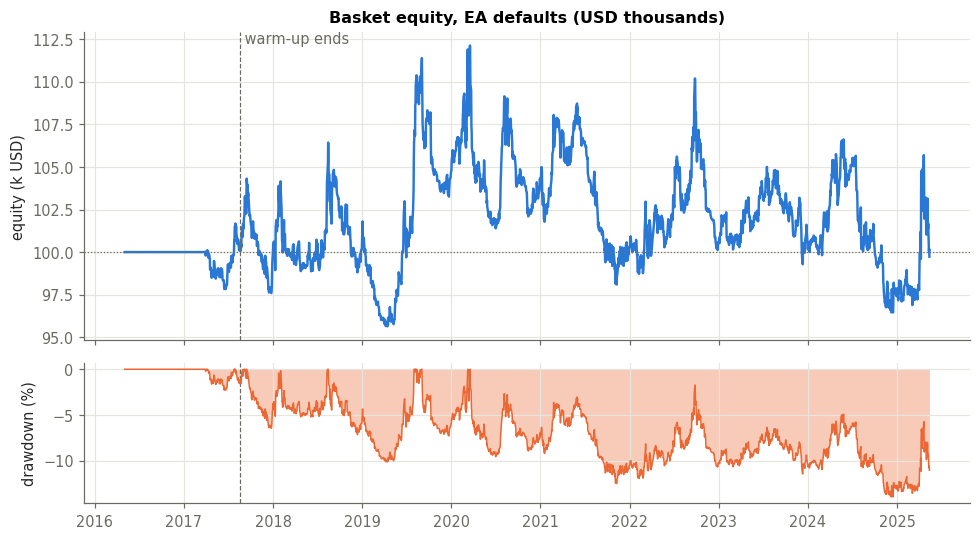

In [9]:
eq = daily["equity"].to_numpy(); dd = eq / np.maximum.accumulate(eq) - 1
t = daily["date"].to_numpy()
fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
axs[0].plot(t, eq / 1e3, color="#2a78d6"); axs[0].axhline(EQUITY0 / 1e3, color=MUTED, lw=0.8, ls=":")
axs[0].set(title="Basket equity, EA defaults (USD thousands)", ylabel="equity (k USD)")
for ax in axs: ax.axvline(EVAL_START, color=MUTED, lw=0.8, ls="--")
axs[0].text(EVAL_START, axs[0].get_ylim()[1], " warm-up ends", color=MUTED, va="top")
axs[1].fill_between(t, dd * 100, 0, color="#eb6834", alpha=0.35, lw=0); axs[1].plot(t, dd * 100, color="#eb6834", lw=1)
axs[1].set(ylabel="drawdown (%)"); plt.tight_layout(); plt.show()

In [10]:
print("Yearly Sharpe (the EA's OnTester input):")
display(ont["yearly"].select("year", "days", "sharpe"))
contrib = (trades.group_by("symbol").agg(pl.len().alias("legs"), pl.col("pnl").sum().alias("net P&L (USD)"),
                                         pl.col("pnl_price").sum().alias("price P&L"), pl.col("swap").sum().alias("swap"))
           .sort("net P&L (USD)", descending=True))
reasons = trades.group_by("reason").agg(pl.len().alias("legs"), pl.col("pnl").sum().alias("P&L (USD)")).sort("legs", descending=True)
display(contrib); display(reasons)

Yearly Sharpe (the EA's OnTester input):


year,days,sharpe
i32,u32,f64
2017,96,-0.2720
2018,259,0.1412
2019,259,0.6255
2020,260,-0.0459
2021,260,-0.4964
2022,259,0.0732
2023,259,0.1113
2024,261,-0.4173
2025,95,0.4657


symbol,legs,net P&L (USD),price P&L,swap
str,u32,f64,f64,f64
"""XAUUSD""",147,17347.0100,17347.0100,0.0000
"""EURUSD""",190,-267.7600,-267.7600,0.0000
"""NZDCHF""",174,-7050.6144,-7050.6144,0.0000
"""GBPJPY""",182,-10296.2845,-10296.2845,0.0000


reason,legs,P&L (USD)
str,u32,f64
"""signal_exit""",346,-8849.7160
"""scale_down""",317,13847.4674
"""flip""",18,-5560.6591
"""eod""",6,3451.6102
"""stop""",6,-3156.3515


## 7. Behaviour diagnostics
**Why:** before reading anything into the P&L, confirm the mechanics behave as designed:
- Does realised volatility land near the 12% target?
- Is leverage sane?
- How often does each symbol change position (cost drag)?
- Do the stops act only as rare emergency exits?

symbol,position changes / yr,time in market,time at full size,median leg life (days)
str,f64,f64,f64,f64
"""EURUSD""",35.7371,0.7133,0.3492,11.0000
"""GBPJPY""",36.9024,0.6163,0.3160,9.0000
"""NZDCHF""",33.1474,0.5983,0.2850,10.5000
"""XAUUSD""",30.0398,0.6439,0.3414,9.0000


realised vol 7.7% vs target 12%  |  gross leverage: mean 0.96x, max 2.45x  |  stop-outs: 6


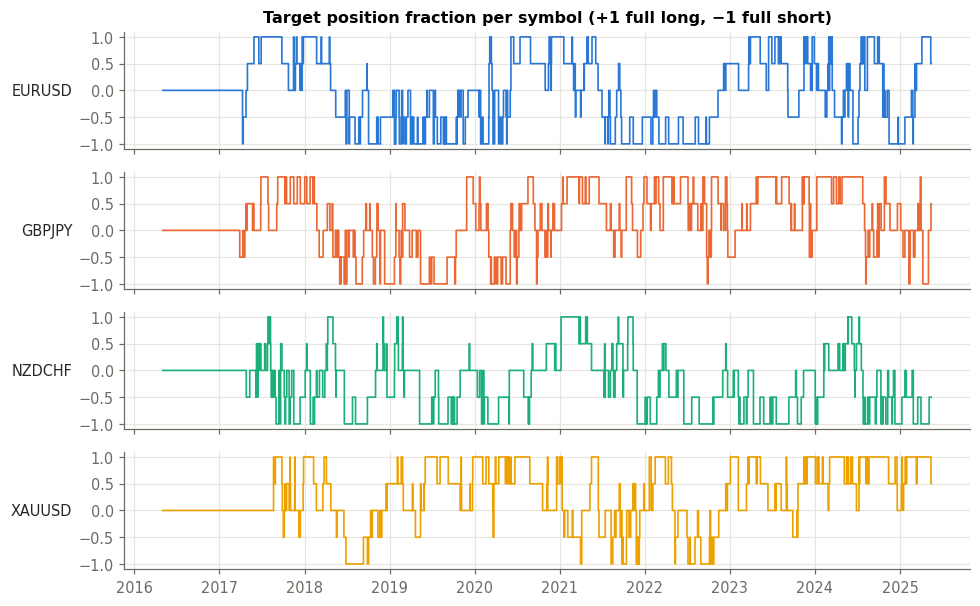

In [11]:
pos = res.positions.with_columns(pl.col("date").dt.year().alias("year"))
chg = (pos.sort("symbol", "date").with_columns((pl.col("lots").diff().over("symbol").fill_null(0) != 0).alias("changed"))
          .group_by("symbol").agg((pl.col("changed").sum() / years).alias("position changes / yr"),
                                  (pl.col("lots") != 0).mean().alias("time in market"),
                                  (pl.col("frac").abs() == 1).mean().alias("time at full size")))
hold = (trades.with_columns(((pl.col("exit_ts") - pl.col("entry_ts")).dt.total_days()).alias("days"))
              .group_by("symbol").agg(pl.col("days").median().alias("median leg life (days)")))
display(chg.join(hold, on="symbol").sort("symbol"))
print(f"realised vol {headline['realised vol (ann.)']:.1%} vs target {PARAMS.portfolio_vol_pct:.0f}%  |  "
      f"gross leverage: mean {daily['gross_leverage'].mean():.2f}x, max {daily['gross_leverage'].max():.2f}x  |  "
      f"stop-outs: {trades.filter(pl.col('reason') == 'stop').height}")

fig, axs = plt.subplots(len(SYMBOLS), 1, figsize=(9, 5.6), sharex=True, sharey=True)
for ax, s in zip(axs, SYMBOLS):
    d = pos.filter(pl.col("symbol") == s)
    ax.step(d["date"].to_numpy(), d["frac"].to_numpy(), where="post", color=COLORS[s], lw=1.1)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1]); ax.set_ylabel(s, rotation=0, ha="right", va="center", color=INK)
axs[0].set_title("Target position fraction per symbol (+1 full long, −1 full short)")
plt.tight_layout(); plt.show()

## 8. Cost sensitivity
**Why:** to separate the signal from its costs. Same parameters, three cost models. These aren't new parameter trials:
- **frictionless:** no spread, slippage or swap. Isolates the raw signal.
- **base:** as in §6.
- **stressed:** DESIGN §4.2 cost-stress gate: 1.5× spread, +1 pip slippage on every fill (each symbol's own pip), stops filled at the bar's extreme.
- **daytime spread (what-if):** same fills, but every bar's spread is replaced by that symbol's 08–20h median from §3. This estimates what trading at the 00:00 rollover costs.
- **rollover-conservative (upper bound):** `costs.conservative_spread` raises each bar's spread to at least that hour's p75 M1 spread over the dev window, then doubles it at 00:00 (spread audit, recommendation 3). The verdict has to hold here too.

In [12]:
# stressed: one model per symbol so "+1 pip" is in each symbol's own points
runs = {"frictionless": (inputs, CostModel.frictionless(COST)), "base": (inputs, COST),
        "stressed": ([replace(si, cost=COST.stressed(spec=specs[si.symbol])) for si in inputs], COST.stressed())}
rows = []
for name, (inp, cm) in runs.items():
    r_ = mt.simulate(inp, PARAMS, cm, equity0=EQUITY0)
    m_ = metrics.summary(evald(r_.daily).select("date", "ret"))
    rows.append({"cost model": name, "version": cm.version, "Sharpe": m_["sharpe"], "CAGR": m_["cagr"],
                 "max DD": m_["max_dd"], "final equity": float(r_.daily["equity"][-1])})

day_spread = dict(zip(day["symbol"], day["day"]))
inputs_day = [mt.SymbolInput(si.symbol, si.bars.with_columns(pl.lit(day_spread[si.symbol]).alias("spread"),
                                                             pl.lit(day_spread[si.symbol]).alias("spread_max")),
                             si.spec, si.rate_open, si.rate_close) for si in inputs]
r_ = mt.simulate(inputs_day, PARAMS, COST, equity0=EQUITY0)
m_ = metrics.summary(evald(r_.daily).select("date", "ret"))
rows.append({"cost model": "daytime spread (what-if)", "version": COST.version + " (spread := 08–20h median)",
             "Sharpe": m_["sharpe"], "CAGR": m_["cagr"], "max DD": m_["max_dd"], "final equity": float(r_.daily["equity"][-1])})
profiles = {s: costs.hourly_spread_profile(s, q=0.75) for s in SYMBOLS}
inputs_cons = [mt.SymbolInput(si.symbol, costs.conservative_spread(si.bars, profiles[si.symbol], rollover_hours=(0,),
                                                                   rollover_mult=2.0),
                              si.spec, si.rate_open, si.rate_close) for si in inputs]
r_ = mt.simulate(inputs_cons, PARAMS, COST, equity0=EQUITY0)
m_ = metrics.summary(evald(r_.daily).select("date", "ret"))
rows.append({"cost model": "rollover-conservative (p75 floor, 2× at 00:00)", "version": COST.version + " (conservative_spread)",
             "Sharpe": m_["sharpe"], "CAGR": m_["cagr"], "max DD": m_["max_dd"], "final equity": float(r_.daily["equity"][-1])})
costs_tbl = pl.DataFrame(rows); costs_tbl

cost model,version,Sharpe,CAGR,max DD,final equity
str,str,f64,f64,f64,f64
"""frictionless""","""fbs-v2-uncalibrated+spread_mul…",0.2669,0.0178,-0.0925,114904.5116
"""base""","""fbs-v2-uncalibrated""",0.0327,-0.0005,-0.1398,99732.3511
"""stressed""","""fbs-v2-uncalibrated+spread_mul…",-0.1341,-0.0133,-0.1988,90095.4023
"""daytime spread (what-if)""","""fbs-v2-uncalibrated (spread :=…",0.2428,0.0158,-0.0954,113087.4090
"""rollover-conservative (p75 flo…","""fbs-v2-uncalibrated (conservat…",-0.3017,-0.0263,-0.2465,80430.7748


## 9. Evidence and findings
**Why:** each finding below rests on a measured number, not on a reading of the charts. This cell computes the four that matter:
- (a) the cost paid per symbol, and each symbol's Sharpe when traded on its own before costs;
- (b) gold's P&L split by long and short side;
- (c) which lookback vote flipped on each signal-driven position change;
- (d) the realised correlation between symbols, against the ρ = 0.3 used for sizing.

In [13]:
fr = mt.simulate(inputs, PARAMS, CostModel.frictionless(COST), equity0=EQUITY0)
cost_by = (fr.trades.group_by("symbol").agg(pl.col("pnl").sum().alias("P&L before costs"))
             .join(trades.group_by("symbol").agg(pl.col("pnl").sum().alias("P&L after costs")), on="symbol")
             .with_columns((pl.col("P&L before costs") - pl.col("P&L after costs")).alias("cost paid")))
solo = {si.symbol: mt.simulate([si], PARAMS, CostModel.frictionless(COST), equity0=EQUITY0).daily for si in inputs}
cost_by = cost_by.with_columns(pl.col("symbol").replace_strict(
    {s: metrics.summary(evald(d).select("date", "ret"))["sharpe"] for s, d in solo.items()}).alias("solo Sharpe, before costs"))
print("(a) cost and standalone edge by symbol"); display(cost_by.sort("symbol"))

print("(b) XAUUSD P&L by side (after costs)")
display(trades.filter(pl.col("symbol") == "XAUUSD").group_by("direction").agg(pl.len().alias("legs"), pl.col("pnl").sum().alias("P&L")))

lbs = PARAMS.resolved_lookbacks(); flips = {L: 0 for L in lbs}; n_chg = only_fast = 0
for s in SYMBOLS:
    c = bars[s]["close"]; sig = (c / c.shift(1)).log().rolling_std(PARAMS.vol_period)
    V = np.stack([np.sign(((c / c.shift(L)).log() / (sig * math.sqrt(L))).fill_null(0).to_numpy()) for L in lbs])
    row_of = {d: i for i, d in enumerate(bars[s]["ts"].dt.date().to_list())}
    p_ = res.positions.filter(pl.col("symbol") == s).sort("date")
    lots, dates = p_["lots"].to_numpy(), p_["date"].to_list()
    for k in range(1, len(lots)):
        t_ = row_of[dates[k]] - 1                        # the decision used bar t_ (previous close)
        if abs(lots[k] - lots[k - 1]) < 1e-12 or dates[k] < EVAL_START or t_ < 1:
            continue
        flipped = [L for j, L in enumerate(lbs) if V[j, t_] != V[j, t_ - 1]]
        if flipped:
            n_chg += 1; only_fast += flipped == [lbs[0]]
            for L in flipped: flips[L] += 1
print(f"(c) {n_chg} signal-driven position changes; share in which each vote flipped:",
      {f"{L}d": f"{v / n_chg:.0%}" for L, v in flips.items()}, f"| the {lbs[0]}d vote alone: {only_fast / n_chg:.0%}")

R = pl.concat([evald(d).select("date", pl.col("ret").alias(s)) for s, d in solo.items()], how="align").fill_null(0)
C = np.corrcoef(R.select(SYMBOLS).to_numpy().T); iu = np.triu_indices(len(SYMBOLS), 1)
print(f"(d) realised pairwise correlation of symbol returns: mean {C[iu].mean():.2f} "
      f"(range {C[iu].min():.2f} to {C[iu].max():.2f}); sizing assumed {PARAMS.assumed_corr}")

(a) cost and standalone edge by symbol


symbol,P&L before costs,P&L after costs,cost paid,"solo Sharpe, before costs"
str,f64,f64,f64,f64
"""EURUSD""",1412.3400,-267.7600,1680.1000,0.0258
"""GBPJPY""",-7636.3095,-10296.2845,2659.9751,-0.2608
"""NZDCHF""",1557.4211,-7050.6144,8608.0355,0.1401
"""XAUUSD""",19571.0600,17347.0100,2224.0500,0.6764


(b) XAUUSD P&L by side (after costs)


direction,legs,P&L
i8,u32,f64
-1,45,-3015.3300
1,102,20362.3400


(c) 848 signal-driven position changes; share in which each vote flipped: {'20d': '47%', '60d': '29%', '120d': '20%', '240d': '15%'} | the 20d vote alone: 40%
(d) realised pairwise correlation of symbol returns: mean 0.10 (range -0.00 to 0.23); sizing assumed 0.3


### Findings
**1. The port is trustworthy.**
- The M1-built D1 bars match the MT5 exports to the point, the 33 unit tests pass, the look-ahead audit passes, and the simulator matches the engine fill for fill.
- The red team also truncated and perturbed the future of the full scaled, vol-targeted run at three dates: there was no change before the cut. It found no blockers, and the logic matches the EA line by line.

**2. After costs, the defaults show no edge.** Sharpe 0.03 (t ≈ 0.1) over 7.7 years, max drawdown −14%, and a drawdown lasting 1,339 days.

**3. Even before costs, the edge is weak and comes from gold alone** (table a).
- Before costs, the basket's Sharpe is 0.27 (t ≈ 0.7).
- Traded alone before costs, XAUUSD makes about 0.7, while the FX pairs range from about −0.26 to 0.14.
- Gold's longs carry it (table b). Gold roughly doubled in this window, so a large part of that is simply being long a rising asset.
- One standard error of an annual Sharpe over 7.7 years is about 0.36, so none of these per-symbol differences is meaningful. **They must not be used to pick symbols.**

**4. Costs: the timing diagnosis holds, but fixing it only restores the weak pre-cost edge.**
- Costs total about $15k. NZDCHF alone pays about $8.6k, because of its 00:00 rollover spread (§3).
- Using daytime spreads recovers about 88% of the cost (Sharpe 0.24).
- The red team re-ran with real H1 fills at 01:00, 02:00 and 10:00 and got 0.12, 0.20 and 0.235. So the effect is real.
- The ceiling is the pre-cost 0.27, which isn't significant.
- At the conservative upper bound from the spread audit (hour-of-day p75 floor, 2× at 00:00) the baseline falls to **−0.30**. The verdict holds whichever spread reading is right.

**5. Turnover:** 30–37 position changes per symbol per year (table c).
- The 20-day vote flips in about half of the signal-driven changes, and is the only vote to flip in about 40% of them. Slower votes drive the rest.
- So the turnover comes from the vote-plus-scaling design as a whole, not from one lookback.
- The red team also found an EA design flaw: after one leg of a scaled position is stopped out, the remaining half leg is treated as a full position.

**6. Sizing:** realised volatility is 7.7% against the 12% target.
- Average position size is only about 0.54 of full.
- Realised correlation between symbols is about 0.10 (table d), so the assumed ρ = 0.3 is conservative.
- Stops act only as emergency exits: 6 fired.

**7. Swap is missing exactly where the money is.** The red team's estimate: gold-long carry would cost about 0.04–0.08 Sharpe. The FX carry sign is unknown until the broker specs are exported.

**8. Power: this design cannot pass the gates on the data we have.**
- The statistician ran `quantlab.stats.power_check` on the full ~30-symbol basket. Over 7.7 years the gates need an after-cost Sharpe of about 1.0–1.35 at 10–30 trials. Even at a single trial, the CPCV ≥ 1.0 and MinTRL gates still bind.
- The literature points to about 0.2–0.5 after costs for FX + metals trend: FX crosses share a handful of currency factors, so the effective breadth is about 8–10, not 30.
- Verdict: **kill early** at S1. The 4-symbol subset is never testable on its own.

**Recommendation:** don't open a research cycle for this design. Record it as killed before a card exists (a negative result, kept so it isn't retested), and keep the port and simulator as reusable tools. If the EA keeps running in MT5 for learning, set a daytime execution hour. Next steps are in the session summary and the Obsidian card.

## 10. Why the early kill
**Why:** "kill early" is a statistical verdict, so this section shows the arithmetic behind it. It uses the project's own gate code (`quantlab.stats`, the same functions the S1 and S5 stages call). No new strategy variants are run, so nothing here adds trials.

**The gates** (DESIGN §4.2, all on daily returns after costs) that matter here:
- **DSR ≥ 0.95.** The Sharpe must beat the best result you'd expect from N tries by pure luck (Bailey & López de Prado, 2014).
- **MinTRL ≤ the data we have.** The track record must be long enough to show the Sharpe is above 0 with 95% confidence (Bailey & López de Prado, 2012).
- **OOS Sharpe ≥ 1.0**, the median over the CPCV out-of-sample paths.
- **Cost stress > 0.5.**
- **Time stability:** positive in at least 60% of years, and no year above 40% of the P&L.

**10a. The scoreboard.** This is the baseline as if it were the only configuration ever tried (N = 1), which is its best possible treatment. The before-costs column shows that even a perfect cost fix fails.

In [14]:
PPY = 260.0
def gate_row(d, label):
    r = evald(d)["ret"].to_numpy(); n = r.size
    sr_d = r.mean() / r.std(ddof=1); g3 = float(((r - r.mean()) ** 3).mean() / r.std() ** 3)
    g4 = float(((r - r.mean()) ** 4).mean() / r.std() ** 4)
    eq_ = evald(d).with_columns(pl.col("date").dt.year().alias("y"))
    yr = eq_.group_by("y").agg(((1 + pl.col("ret")).product() - 1).alias("ret")).sort("y")["ret"].to_numpy()
    pos = yr[yr > 0]
    return {"run": label, "Sharpe": sr_d * math.sqrt(PPY),
            "DSR prob (N=1)": stats.psr(sr_d, 0.0, n, g3, g4),
            "MinTRL (years)": stats.min_trl(sr_d, 0.0, g3, g4, 0.95, PPY)["years"],
            "positive years": float((yr > 0).mean()),
            "best year share of P&L": float(yr.max() / yr[yr > 0].sum()) if pos.size else float("nan")}
score = pl.DataFrame([gate_row(daily, "after costs (base)"), gate_row(fr.daily, "before costs")])
stressed_sr = float(costs_tbl.filter(pl.col("cost model") == "stressed")["Sharpe"][0])
avail = years
net, gross = score.to_dicts()
mark = lambda ok: "–" if ok is None else ("✔" if ok else "✘")
rows = [  # (gate, threshold test, value formatter, metric key)
    ("DSR prob ≥ 0.95 (N = 1)", lambda v: v >= 0.95, "{:.2f}", "DSR prob (N=1)"),
    (f"MinTRL ≤ {avail:.1f} years", lambda v: v <= avail, "{:.0f} y", "MinTRL (years)"),
    ("OOS Sharpe ≥ 1.0 (full-sample proxy)", lambda v: v >= 1.0, "{:.2f}", "Sharpe"),
    ("positive years ≥ 60%", lambda v: v >= 0.6, "{:.0%}", "positive years"),
    ("best year ≤ 40% of P&L", lambda v: v <= 0.4, "{:.0%}", "best year share of P&L"),
]
table = [{"gate": g, "after costs": f.format(net[k]), "pass": mark(t(net[k])),
          "before costs": f.format(gross[k]), "pass ": mark(t(gross[k]))} for g, t, f, k in rows]
table.insert(3, {"gate": "cost-stress Sharpe > 0.5", "after costs": f"{stressed_sr:.2f}",
                 "pass": mark(stressed_sr > 0.5), "before costs": "n/a", "pass ": "–"})
pl.DataFrame(table)

gate,after costs,pass,before costs,pass
str,str,str,str,str
"""DSR prob ≥ 0.95 (N = 1)""","""0.54""","""✘""","""0.77""","""✘"""
"""MinTRL ≤ 7.7 years""","""2532 y""","""✘""","""38 y""","""✘"""
"""OOS Sharpe ≥ 1.0 (full-sample …","""0.03""","""✘""","""0.27""","""✘"""
"""cost-stress Sharpe > 0.5""","""-0.13""","""✘""","""n/a""","""–"""
"""positive years ≥ 60%""","""56%""","""✘""","""67%""","""✔"""
"""best year ≤ 40% of P&L""","""56%""","""✘""","""39%""","""✔"""


**10b. How high is the bar, and how far away are we?**
- **Left:** the Sharpe the DSR gate demands over our 7.7 years, as trials accumulate. A real study (grid search, variants) easily reaches 10–30 trials. The OOS ≥ 1.0 gate is a floor regardless.
- **Middle:** MinTRL, the years of data needed to trust a given Sharpe. Below about 0.6 it exceeds the data we have.
- **Right:** the probability that a system with a given *true* Sharpe passes the DSR gate on our data, P ≈ Φ((SR − SR_required) / SE), with SE ≈ √((1 + SR²/2)/T) (Lo, 2002).

The shaded band is the realistic after-cost prior for FX + metals trend: 0.2–0.5 (Moskowitz et al., 2012; Hurst et al., 2017; Baltas & Kosowski, 2013).

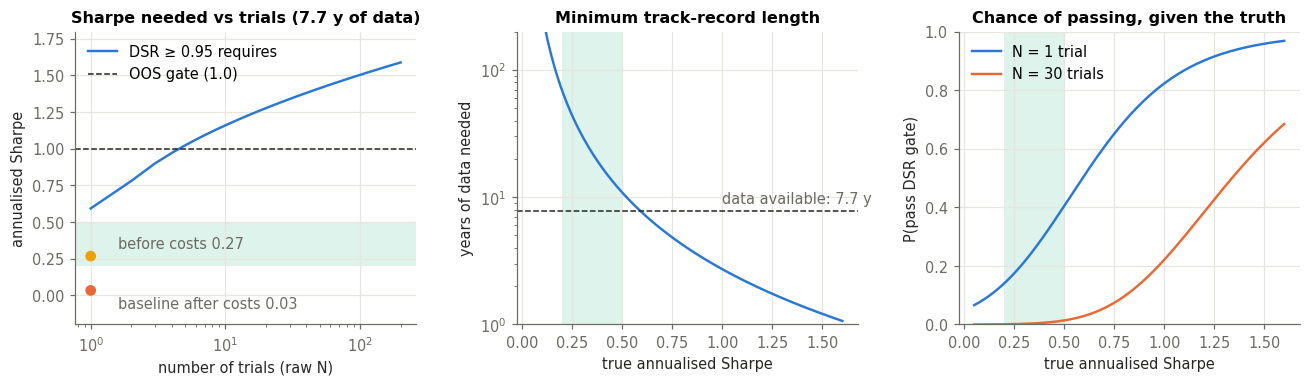

expected Sharpe,trials,MinTRL (y),Sharpe required by DSR,expected DSR,S1 feasible
f64,i64,f64,f64,f64,bool
0.3000,1,30.1000,0.5900,0.8000,false
0.3000,30,30.1000,1.3400,0.1100,false
0.5000,1,10.8000,0.5900,0.9200,false
0.5000,30,10.8000,1.3400,0.2500,false
0.7000,1,5.5000,0.5900,0.9700,true
0.7000,30,5.5000,1.3400,0.4500,false
1.0000,1,2.7000,0.5900,1.0000,true
1.0000,30,2.7000,1.3400,0.7600,false
1.3000,1,1.6000,0.5900,1.0000,true


In [15]:
n_obs = evald(daily).height
N = np.unique(np.round(np.logspace(0, np.log10(200), 40)).astype(int))
req = np.array([stats.dsr_required_sharpe(n_, n_obs) * math.sqrt(PPY) for n_ in N])
SR = np.linspace(0.05, 1.6, 200)
mtrl = np.array([stats.min_trl(x / math.sqrt(PPY), periods_per_year=PPY)["years"] for x in SR])
PRIOR = (0.2, 0.5); BAND = dict(color="#1baf7a", alpha=0.15, lw=0)
obs_net, obs_gross = score["Sharpe"][0], score["Sharpe"][1]

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].axhspan(*PRIOR, **BAND); ax[0].plot(N, req, color="#2a78d6", label="DSR ≥ 0.95 requires")
ax[0].axhline(1.0, color=INK, lw=1, ls="--", label="OOS gate (1.0)")
ax[0].scatter([1, 1], [obs_net, obs_gross], color=["#eb6834", "#eda100"], s=36, zorder=3)
ax[0].annotate(f"baseline after costs {obs_net:.2f}", (1, obs_net), xytext=(1.6, obs_net - 0.12), color=MUTED)
ax[0].annotate(f"before costs {obs_gross:.2f}", (1, obs_gross), xytext=(1.6, obs_gross + 0.05), color=MUTED)
ax[0].set(xscale="log", xlabel="number of trials (raw N)", ylabel="annualised Sharpe", ylim=(-0.2, 1.8),
          title="Sharpe needed vs trials (7.7 y of data)"); ax[0].legend(loc="upper left")

ax[1].axvspan(*PRIOR, **BAND); ax[1].plot(SR, mtrl, color="#2a78d6")
ax[1].axhline(avail, color=INK, lw=1, ls="--"); ax[1].text(1.0, avail * 1.15, f"data available: {avail:.1f} y", color=MUTED)
ax[1].set(yscale="log", ylim=(1, 200), xlabel="true annualised Sharpe", ylabel="years of data needed",
          title="Minimum track-record length")

for n_, col in [(1, "#2a78d6"), (30, "#eb6834")]:
    r_ = stats.dsr_required_sharpe(n_, n_obs) * math.sqrt(PPY)
    se = np.sqrt((1 + SR ** 2 / 2) / avail)
    from scipy.stats import norm
    ax[2].plot(SR, norm.cdf((SR - r_) / se), color=col, label=f"N = {n_} trial{'s' if n_ > 1 else ''}")
ax[2].axvspan(*PRIOR, **BAND); ax[2].set(xlabel="true annualised Sharpe", ylabel="P(pass DSR gate)", ylim=(0, 1),
                                         title="Chance of passing, given the truth"); ax[2].legend(loc="upper left")
plt.tight_layout(); plt.show()

pc = []
for sr_ in (0.3, 0.5, 0.7, 1.0, 1.3):
    for n_ in (1, 30):
        r_ = stats.power_check(sr_, trades_per_year=100, years_available=avail, n_trials=n_)
        pc.append({"expected Sharpe": sr_, "trials": n_, "MinTRL (y)": round(r_["min_trl_years"], 1),
                   "Sharpe required by DSR": round(r_["dsr_required_sr_annual"], 2),
                   "expected DSR": round(r_["expected_dsr"], 2), "S1 feasible": r_["feasible"]})
pl.DataFrame(pc)

**Reading it:**
- After costs, the baseline fails every gate in the scoreboard. Before costs it still fails all but the time-stability checks.
- To pass, the true Sharpe after costs has to be **at least about 1.0** (the OOS gate), and about 1.3 at a realistic trial count. MinTRL alone rules out anything below about 0.6.
- The realistic prior band (0.2–0.5) sits far below that. Even at its top, the chance of passing at N = 30 is under 5%.
- That is the early kill. The idea isn't wrong; it's undetectable with this data at this bar.

## 11. Can the idea be saved?
**Why:** before discarding the idea, check whether any change could realistically close the gap: the after-cost Sharpe has to rise from about 0.03 to at least 1.0.

**Breadth arithmetic.** With N symbols, each with Sharpe *s*, and average pairwise correlation ρ, the portfolio Sharpe is ≈ s·√(N / (1 + (N−1)ρ)) (Grinold & Kahn, 2000, fundamental law of active management).

**Sanity check on our run:** the four standalone before-cost Sharpes (9a) average *s* ≈ 0.15 with ρ ≈ 0.10. The formula predicts about 0.27 for the basket, and we observed 0.27. So the formula describes this system well, and we can extrapolate with it.

breadth formula with s = 0.15, rho = 0.10, N = 4 -> 0.26  (observed before costs: 0.27)


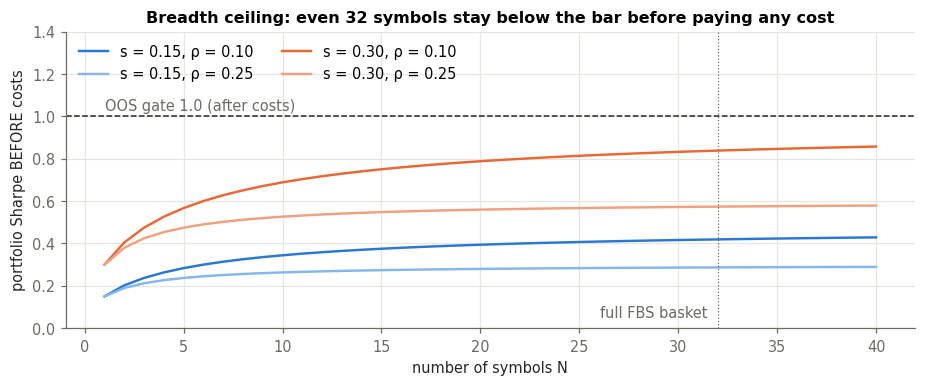

per-symbol s,rho,N = 4,N = 10,N = 32
f64,f64,f64,f64,f64
0.1500,0.1000,0.2631,0.3441,0.4191
0.1500,0.2500,0.2268,0.2631,0.2869
0.3000,0.1000,0.5262,0.6882,0.8381
0.3000,0.2500,0.4536,0.5262,0.5737


In [16]:
s_obs = float(cost_by["solo Sharpe, before costs"].mean()); rho_obs = float(C[iu].mean())
pred = lambda s_, n_, r_: s_ * np.sqrt(n_ / (1 + (n_ - 1) * r_))
print(f"breadth formula with s = {s_obs:.2f}, rho = {rho_obs:.2f}, N = 4 -> {pred(s_obs, 4, rho_obs):.2f}  "
      f"(observed before costs: {obs_gross:.2f})")

Ns = np.arange(1, 41)
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for (s_, r_), col in zip([(0.15, 0.10), (0.15, 0.25), (0.30, 0.10), (0.30, 0.25)],
                         ["#2a78d6", "#86b6ef", "#eb6834", "#f2a07f"]):
    ax.plot(Ns, pred(s_, Ns, r_), color=col, label=f"s = {s_:.2f}, ρ = {r_:.2f}")
ax.axhline(1.0, color=INK, lw=1, ls="--"); ax.text(1, 1.03, "OOS gate 1.0 (after costs)", color=MUTED)
ax.axvline(32, color=MUTED, lw=0.8, ls=":"); ax.text(31.5, 0.05, "full FBS basket", color=MUTED, ha="right")
ax.set(xlabel="number of symbols N", ylabel="portfolio Sharpe BEFORE costs", ylim=(0, 1.4),
       title="Breadth ceiling: even 32 symbols stay below the bar before paying any cost")
ax.legend(ncol=2, loc="upper left"); plt.tight_layout(); plt.show()

pl.DataFrame([{"per-symbol s": s_, "rho": r_, "N = 4": pred(s_, 4, r_), "N = 10": pred(s_, 10, r_),
               "N = 32": pred(s_, 32, r_)} for s_ in (0.15, 0.30) for r_ in (0.10, 0.25)])

**What each kind of change can do** (expected effect on the after-cost Sharpe; none of it was tested here, to avoid more looks):

| Change | What it does | Can it reach ≥ 1.0? |
|---|---|---|
| **Tune parameters** (lookbacks, z_min, ER threshold, stop) | Re-weights the same trend signal. Literature Sharpes barely move across reasonable lookbacks. Every variant tried raises the DSR bar (10b, left). | **No.** It would need a 4–5× higher gross Sharpe (1.0–1.34 vs 0.27), and it makes the bar higher. |
| **Remove indicators** (drop the ER filter or the 20-day vote) | Fewer parameters and less turnover. The 20-day vote drives about half of the trades (9c). | **No.** It cuts costs (net moves toward gross, ≤ 0.27 here) but adds no edge. Worth doing in any future version. |
| **Fix execution** (daytime hour, rebalance buffer) | Recovers most of the cost drag (red team: 0.235 at 10:00). | **No.** The ceiling is the gross 0.27. Necessary, not sufficient. |
| **More symbols** (full FBS FX + metals basket) | More breadth, but FX crosses share about 8 currency drivers, so ρ rises. | **Unlikely.** At the observed per-symbol 0.15 it's 0.29–0.42 *before* costs. Even an optimistic 0.30 per symbol only reaches 0.57–0.84 (table above). |
| **Add a different return source:** FX carry (swap), and/or crypto trend | Carry is a separate, documented premium with low correlation to trend (Menkhoff et al., 2012; Koijen et al., 2018). Crypto adds independent drivers with a stronger trend record (Liu & Tsyvinski, 2021). | **Possible.** These are new hypotheses, so they need new cards and their own trial budget. |
| **More history** (e.g. 20+ years of daily FX from another source) | Relaxes MinTRL. At a Sharpe of 0.5 it needs about 11 years. | **Partly.** It makes a modest Sharpe *detectable*, but the OOS ≥ 1.0 gate still blocks it. It's a policy decision, since the data must still model FBS costs. |
| **Change the role:** trend as a diversifier or crisis hedge inside a portfolio | Judged by marginal contribution to the book (S9), not standalone Sharpe. | Not under the current gates. It needs a DESIGN decision (a portfolio-component path). |

**Bottom line:** no parameter or indicator change can save *this* system under the current gates. The math in §10–11 shows a 4–5× gap that tweaks can't close and that each tweak makes wider. What can survive is the building blocks (the vote, vol targeting, execution fixes) inside a new hypothesis with a different return source, or a policy change that values diversifiers.

## 12. Run record
**Why:** the project requires every evaluated parameter set to be logged (DESIGN §8), because the trial count feeds the Deflated Sharpe ratio later (Bailey & López de Prado, 2014).

A ledger study needs a hypothesis-card issue number, and this idea doesn't have one yet. So the run is saved to `results/run_record.json` and backfilled into the ledger when the card is created.
- **Trials used so far: 1.** The §5 parity run and the §8 cost variants don't count: they reuse the same parameters.
- **Post-hoc looks: 4,** each logged in the record: the daytime-spread what-if, plus three execution-hour probes run by the red team (01:00, 02:00, 10:00). Any later study must declare them as `prior_trials`.

In [17]:
record = {"system": "manahl_trend", "book": "FBS", "kind": "exploratory mechanics run (pre-card)", "trials": 1,
          # post-hoc looks at dev data motivated by this run; declare as prior_trials in any later study
          "post_hoc_looks": ["daytime-spread what-if (notebook §8)",
                             "red-team probe 2026-10-07: execution at 01:00, 02:00, 10:00 server time (3 looks)"],
          "created": datetime.now().isoformat(timespec="seconds"), "git_commit": ledger.git_commit(),
          "data_manifest_sha": ledger.manifest_sha(), "symbols": SYMBOLS, "timeframe": "D1",
          "dev_window": [str(daily["date"].min()), str(daily["date"].max())], "eval_start": str(EVAL_START), "params": PARAMS.as_dict(),
          "cost_model_version": COST.version, "specs_calibrated": {s: sp.calibrated for s, sp in specs.items()},
          "metrics": {k: float(v) for k, v in headline.items()},
          "cost_sensitivity": costs_tbl.select("cost model", "Sharpe", "CAGR", "max DD").to_dicts()}
(OUT_DIR / "run_record.json").write_text(json.dumps(record, indent=2, default=str))
daily.write_parquet(OUT_DIR / "baseline_daily.parquet"); trades.write_parquet(OUT_DIR / "baseline_trades.parquet")
print("saved:", *sorted(p.name for p in OUT_DIR.iterdir()))

saved: baseline_daily.parquet baseline_trades.parquet run_record.json


### References
- Bailey, D. & López de Prado, M. (2014). The Deflated Sharpe Ratio. *Journal of Portfolio Management* 40(5).
- Baltas, N. & Kosowski, R. (2013). Momentum Strategies in Futures Markets and Trend-Following Funds. SSRN 1968996.
- Carver, R. (2015). *Systematic Trading*. Harriman House. (Volatility targeting; instrument diversification multiplier.)
- Harvey, C., Hoyle, E., Korgaonkar, R., Rattray, S., Sargaison, M. & Van Hemert, O. (2018). The Impact of Volatility Targeting. *Journal of Portfolio Management* 45(1). (Man Group.)
- Bailey, D. & López de Prado, M. (2012). The Sharpe Ratio Efficient Frontier. *Journal of Risk* 15(2). (PSR, MinTRL.)
- Grinold, R. & Kahn, R. (2000). *Active Portfolio Management*, 2nd ed. McGraw-Hill. (Fundamental law: breadth.)
- Hurst, B., Ooi, Y. H. & Pedersen, L. H. (2017). A Century of Evidence on Trend-Following Investing. *Journal of Portfolio Management* 44(1).
- Kaufman, P. (1995). *Smarter Trading*. McGraw-Hill. (Efficiency ratio.)
- Koijen, R., Moskowitz, T., Pedersen, L. H. & Vrugt, E. (2018). Carry. *Journal of Financial Economics* 127(2).
- Liu, Y. & Tsyvinski, A. (2021). Risks and Returns of Cryptocurrency. *Review of Financial Studies* 34(6).
- Lo, A. (2002). The Statistics of Sharpe Ratios. *Financial Analysts Journal* 58(4).
- Menkhoff, L., Sarno, L., Schmeling, M. & Schrimpf, A. (2012). Carry Trades and Global Foreign Exchange Volatility. *Journal of Finance* 67(2).
- Moskowitz, T., Ooi, Y. H. & Pedersen, L. H. (2012). Time Series Momentum. *Journal of Financial Economics* 104(2).
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems*. (Average true range.)